# Notebook 01: Dataset Analysis & Preprocessing for Tomato Crop Disease Classification

**Goal**: Perform exploratory data analysis (EDA), verify dataset integrity, check class distributions, detect corrupted images, and create reproducible, leakage-free train/validation/test splits.

### Target Classes (Tomato)
- `Healthy`
- `Early Blight`
- `Late Blight`
- `Leaf Mold`


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Add repository root to path
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.utils.config import Config
from src.utils.seed import set_seed
from src.utils.download_dataset import create_sample_dataset
from src.preprocessing.dataset import create_splits, is_image_valid

# Set fixed random seed
set_seed(Config.SEED)


[INFO] Random seed set to: 42


## 1. Load & Verify Dataset Directory


In [2]:
data_dir = Config.RAW_DATA_DIR
if not data_dir.exists() or len(list(data_dir.glob("*/*"))) == 0:
    print("[INFO] Raw dataset not found. Generating sample dataset...")
    create_sample_dataset(output_dir=data_dir)
else:
    print(f"[INFO] Raw dataset directory found at: {data_dir}")


[INFO] Raw dataset directory found at: C:\Users\palak\ai-crop-disease-pest-intelligence\data\raw


## 2. Identify Classes & Check Imbalance


       Class  Count  Percentage
Early Blight     40        25.0
     Healthy     40        25.0
 Late Blight     40        25.0
   Leaf Mold     40        25.0


C:\Users\palak\AppData\Local\Temp\ipykernel_28668\1636569309.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_class_counts, x="Class", y="Count", palette="viridis")


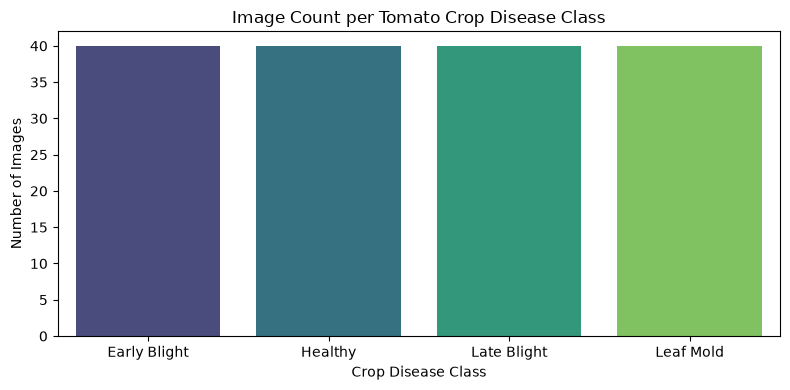

In [3]:
class_counts = {}
for folder_name in os.listdir(data_dir):
    folder_path = data_dir / folder_name
    if folder_path.is_dir():
        std_class = Config.CLASS_FOLDER_MAP.get(folder_name, folder_name)
        if std_class in Config.TARGET_CLASSES:
            count = len([f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
            class_counts[std_class] = class_counts.get(std_class, 0) + count

df_class_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
df_class_counts["Percentage"] = (df_class_counts["Count"] / df_class_counts["Count"].sum()) * 100
print(df_class_counts.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=df_class_counts, x="Class", y="Count", palette="viridis")
plt.title("Image Count per Tomato Crop Disease Class")
plt.ylabel("Number of Images")
plt.xlabel("Crop Disease Class")
plt.tight_layout()
plt.show()


## 3. Check Image Dimensions & Detect Corrupted Images


In [4]:
widths, heights, modes = [], [], []
corrupt_files = []

for folder_name in os.listdir(data_dir):
    folder_path = data_dir / folder_name
    if folder_path.is_dir():
        for file_name in os.listdir(folder_path):
            img_path = folder_path / file_name
            if is_image_valid(img_path):
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    modes.append(img.mode)
            else:
                corrupt_files.append(img_path)

print(f"Total Valid Images Analyzed: {len(widths)}")
print(f"Detected Corrupted Images: {len(corrupt_files)}")
print(f"Width Range: [{min(widths)}, {max(widths)}] - Mean Width: {np.mean(widths):.1f}")
print(f"Height Range: [{min(heights)}, {max(heights)}] - Mean Height: {np.mean(heights):.1f}")
print(f"Image Modes Distribution: {pd.Series(modes).value_counts().to_dict()}")


Total Valid Images Analyzed: 160
Detected Corrupted Images: 0
Width Range: [256, 256] - Mean Width: 256.0
Height Range: [256, 256] - Mean Height: 256.0
Image Modes Distribution: {'RGB': 160}


## 4. Display Sample Images per Class


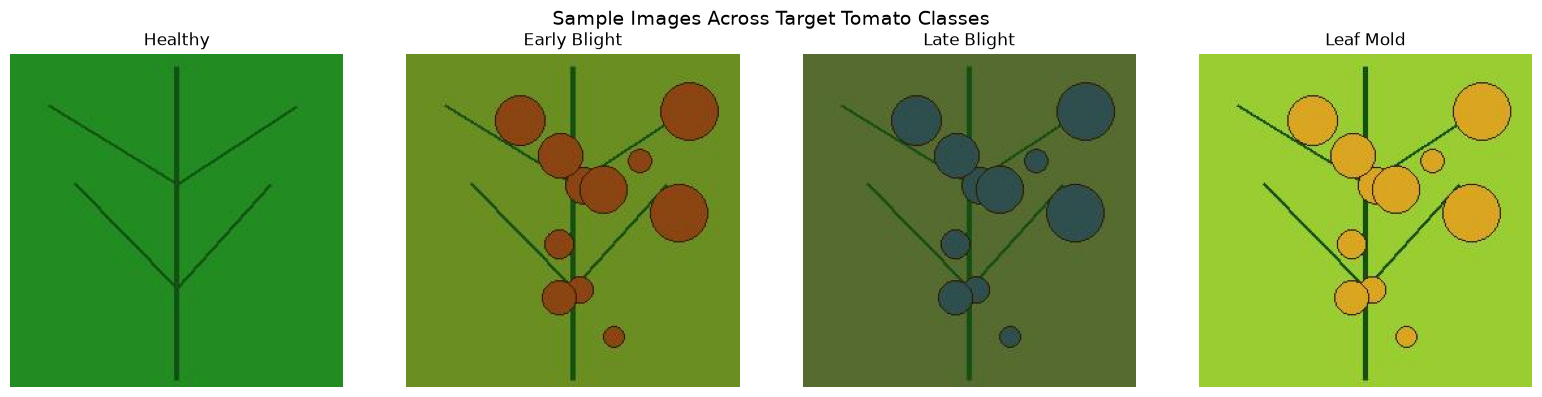

In [5]:
fig, axes = plt.subplots(1, len(Config.TARGET_CLASSES), figsize=(16, 4))
for idx, target_class in enumerate(Config.TARGET_CLASSES):
    matching_folder = None
    for fn in os.listdir(data_dir):
        if Config.CLASS_FOLDER_MAP.get(fn, fn) == target_class:
            matching_folder = data_dir / fn
            break
            
    if matching_folder:
        sample_file = [f for f in os.listdir(matching_folder) if f.lower().endswith((".jpg", ".png"))][0]
        img = Image.open(matching_folder / sample_file)
        axes[idx].imshow(img)
        axes[idx].set_title(target_class)
        axes[idx].axis("off")

plt.suptitle("Sample Images Across Target Tomato Classes", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Create Stratified Train/Val/Test Splits (No Data Leakage)


In [6]:
df_splits = create_splits(data_dir=data_dir, output_csv=Config.SPLITS_CSV_PATH, seed=Config.SEED)

print("\nDistribution across splits:")
split_breakdown = pd.crosstab(df_splits["class_name"], df_splits["split"])
print(split_breakdown)


[INFO] Random seed set to: 42
[INFO] Scanning dataset directory: C:\Users\palak\ai-crop-disease-pest-intelligence\data\raw
[INFO] Created reproducible split manifest saved to: C:\Users\palak\ai-crop-disease-pest-intelligence\data\splits.csv
[INFO] Train samples: 112 | Val samples: 24 | Test samples: 24

Distribution across splits:
split         test  train  val
class_name                    
Early Blight     6     28    6
Healthy          6     28    6
Late Blight      6     28    6
Leaf Mold        6     28    6
